<a href="https://colab.research.google.com/github/Rimal-Rimal/AI/blob/main/RegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/Colab Notebooks/social_media_vs_productivity.csv"

df = pd.read_csv(path)

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nAttributes and Data Types:")

attributes = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values
})

print(attributes)

print("\nCategorical Columns and Unique Values:")

for col in df.select_dtypes(include='object'):
    print(f"\nColumn: {col}")
    print(df[col].unique())

if "Productivity_Score" in df.columns:
    print("\nTarget Variable: Productivity_Score")
    print(df["Productivity_Score"].describe())

elif "Productivity" in df.columns:
    print("\nTarget Variable: Productivity")
    print(df["Productivity"].describe())

else:
    print("\nCheck dataset to identify correct productivity column.")


First 5 Rows:
   age  gender    job_type  daily_social_media_time  \
0   56    Male  Unemployed                 4.180940   
1   46    Male      Health                 3.249603   
2   32    Male     Finance                      NaN   
3   60  Female  Unemployed                      NaN   
4   25    Male          IT                      NaN   

  social_platform_preference  number_of_notifications  work_hours_per_day  \
0                   Facebook                       61            6.753558   
1                    Twitter                       59            9.169296   
2                    Twitter                       57            7.910952   
3                   Facebook                       59            6.355027   
4                   Telegram                       66            6.214096   

   perceived_productivity_score  actual_productivity_score  stress_level  \
0                      8.040464                   7.291555           4.0   
1                      5.063368         

Summary Statistics:
                age  daily_social_media_time  number_of_notifications  \
count  28870.000000             28870.000000             28870.000000   
mean      41.493800                 3.010131                59.877866   
std       13.825519                 1.744263                 7.445548   
min       18.000000                 0.000000                40.000000   
25%       30.000000                 1.779212                55.000000   
50%       41.000000                 3.025913                60.000000   
75%       53.000000                 4.165687                65.000000   
max       65.000000                 7.845437                80.000000   

       work_hours_per_day  perceived_productivity_score  \
count        28870.000000                  28870.000000   
mean             7.011728                      5.511461   
std              1.970498                      1.966981   
min              1.580464                      2.000252   
25%              5.664363  

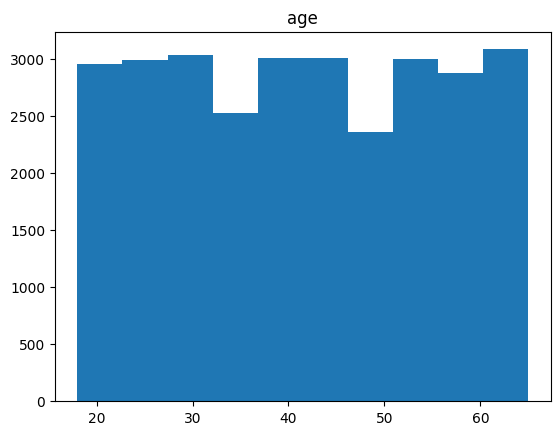

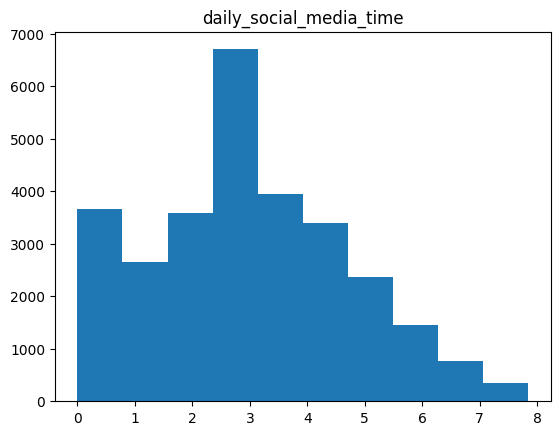

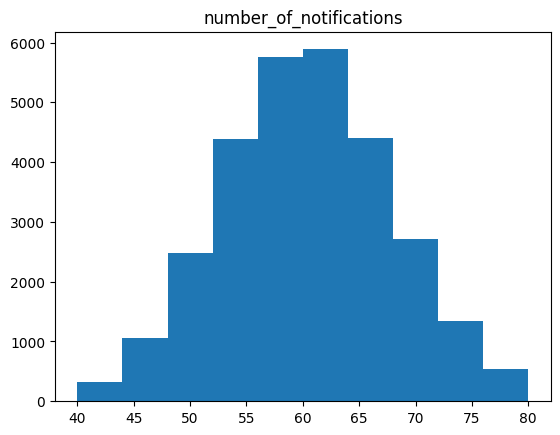

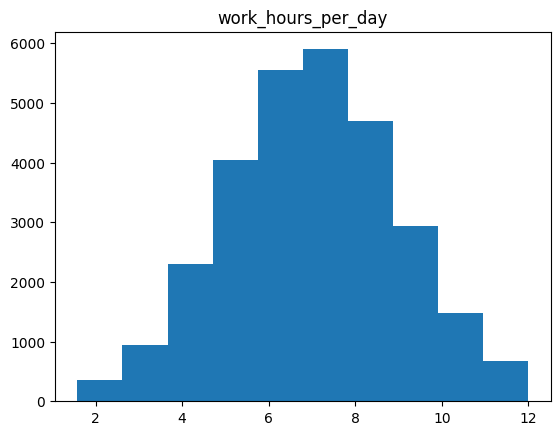

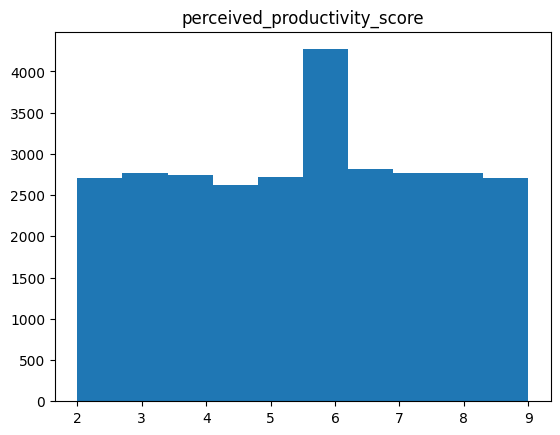

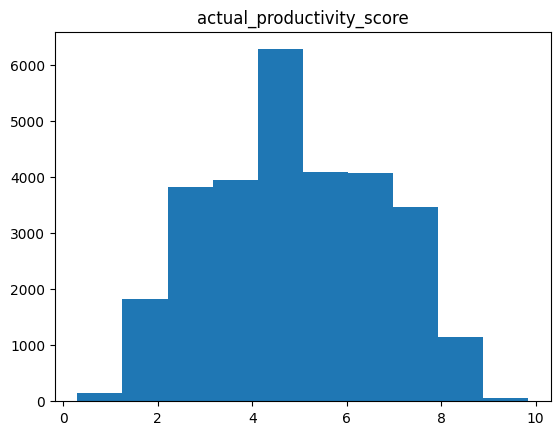

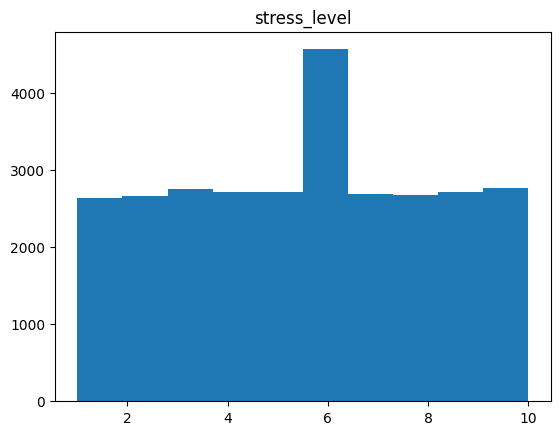

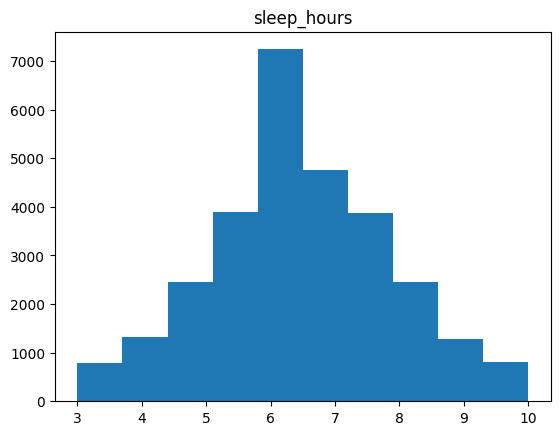

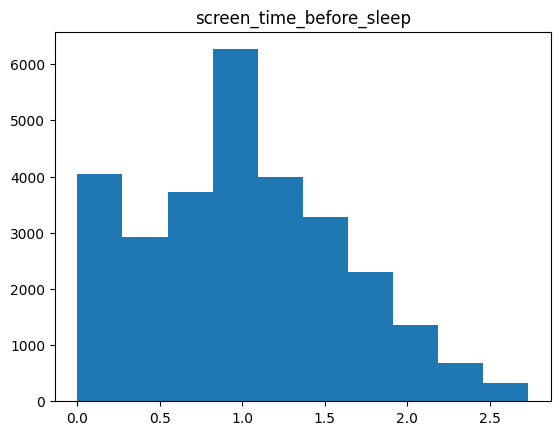

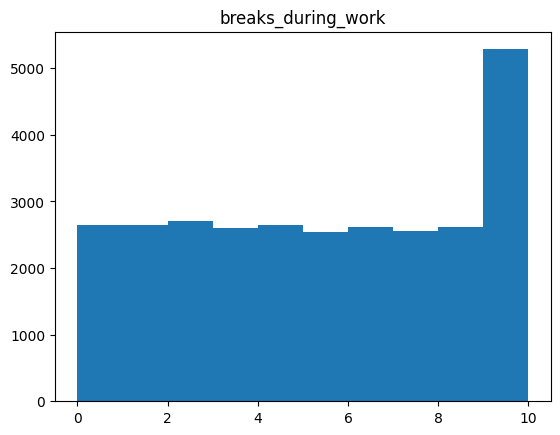

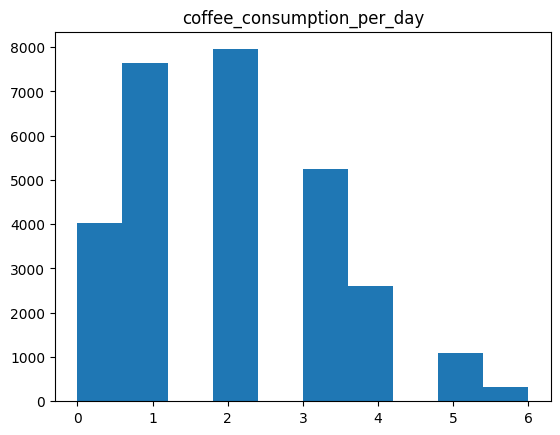

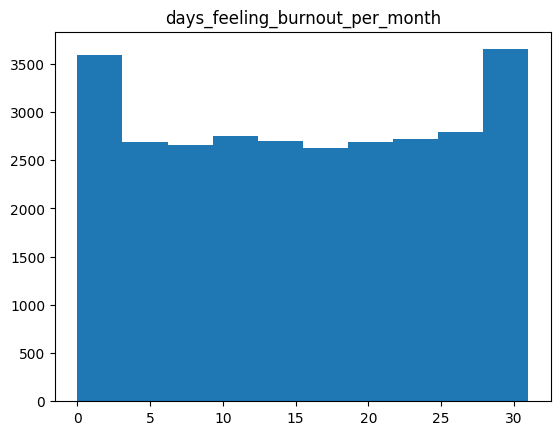

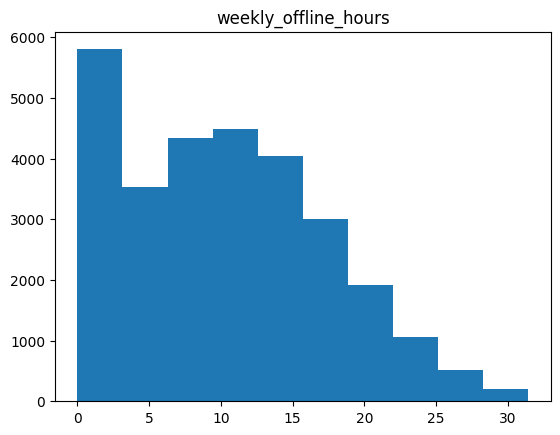

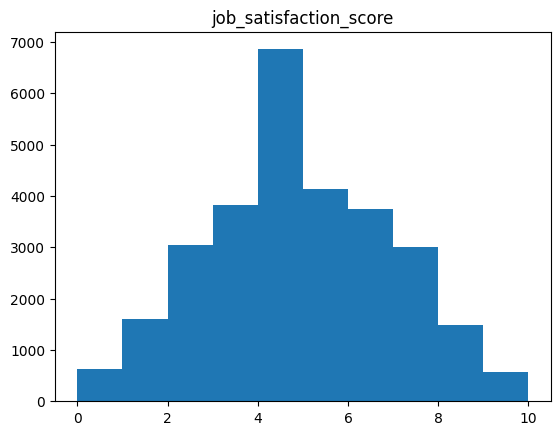

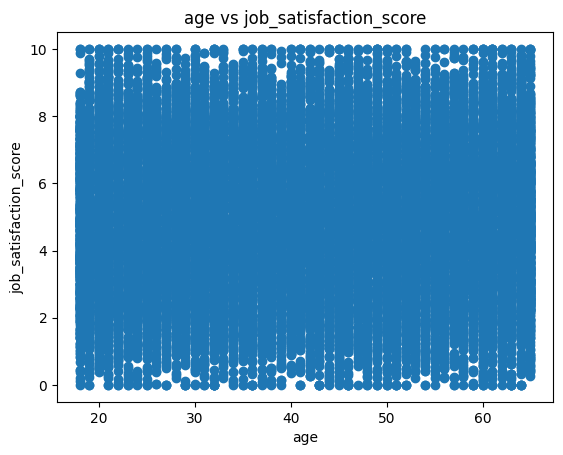

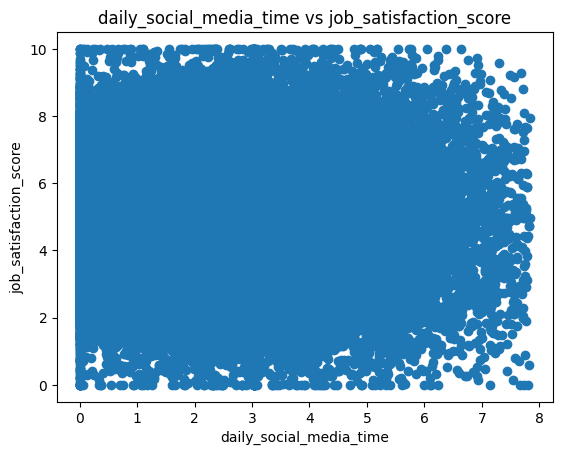

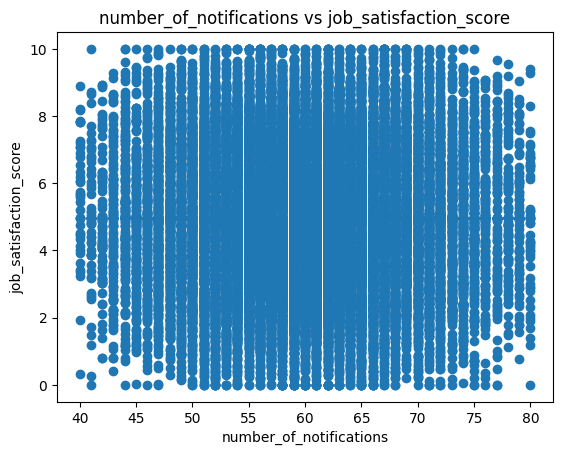

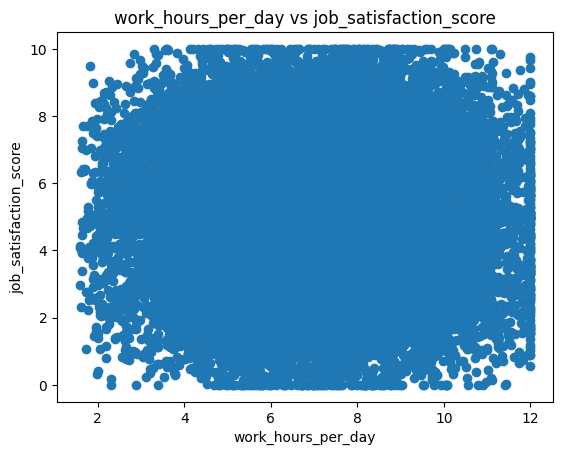

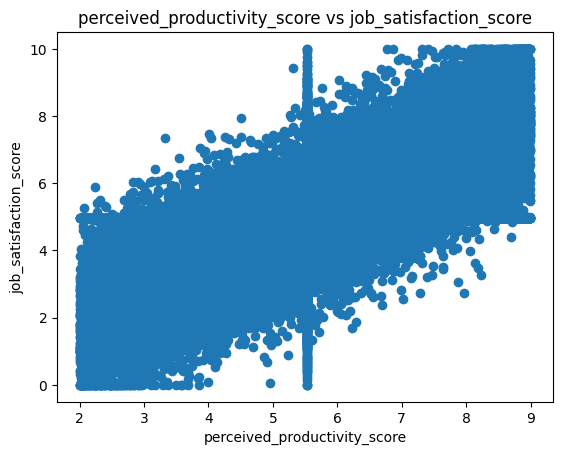

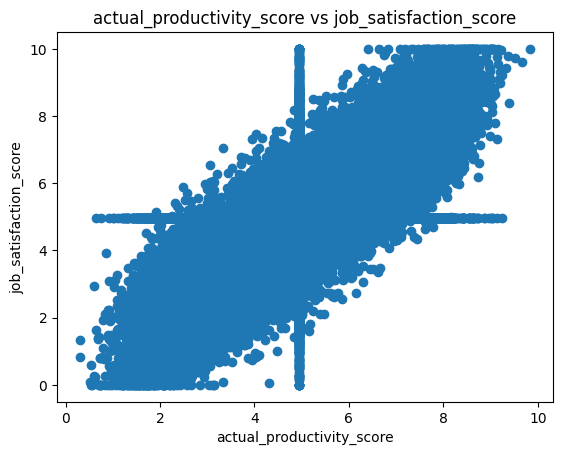

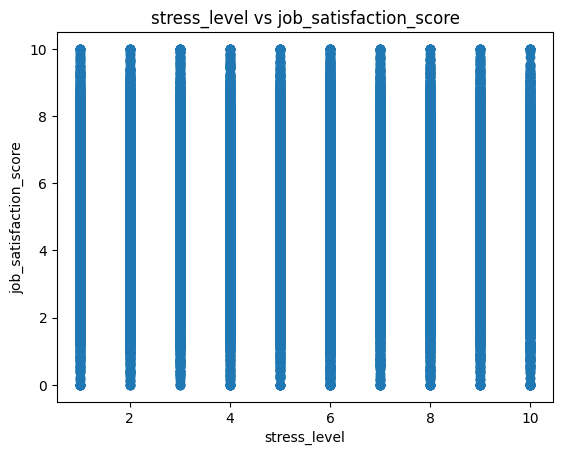

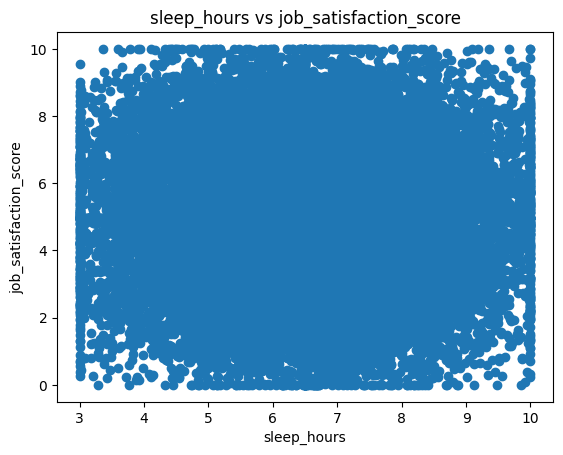

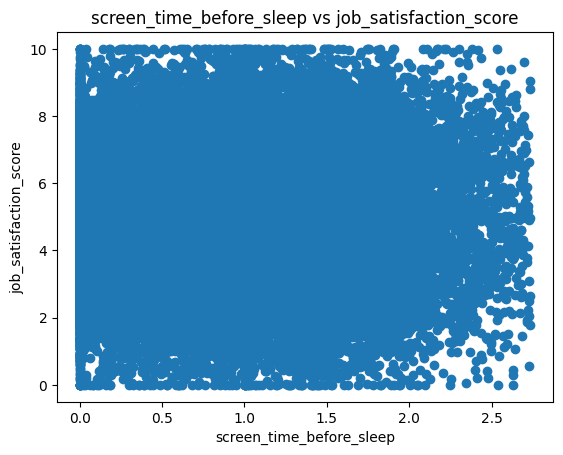

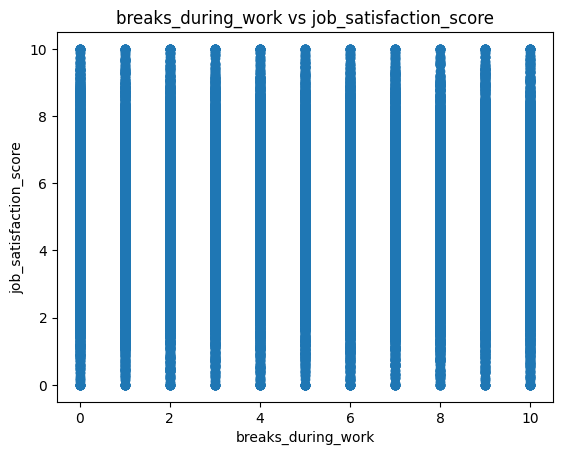

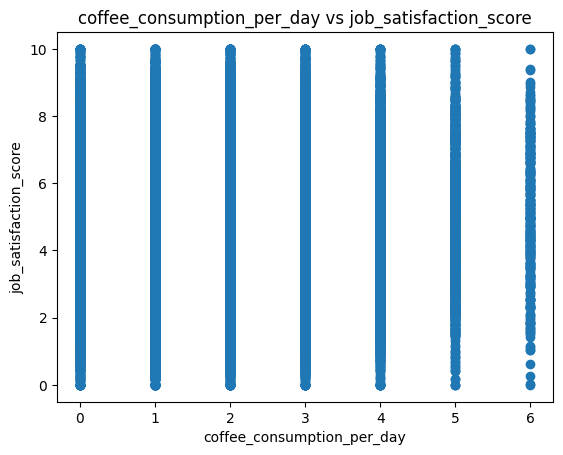

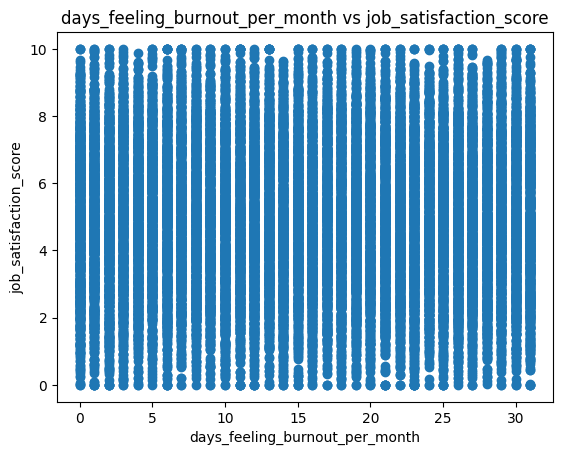

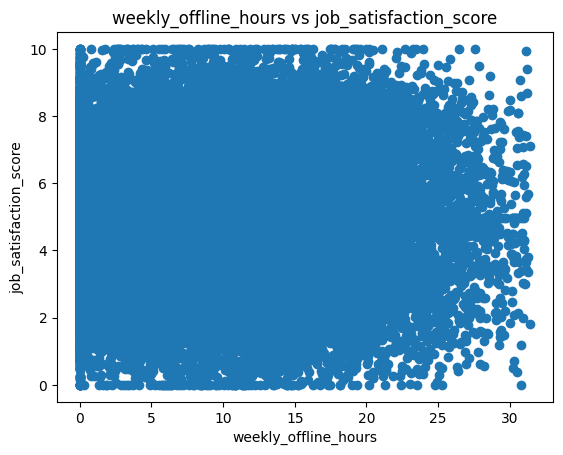

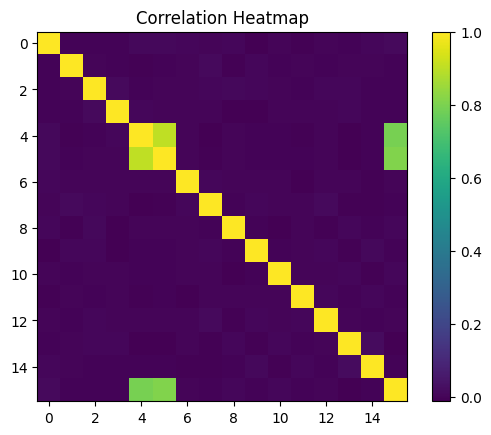

In [ ]:
#TASK 1.2
import matplotlib.pyplot as plt
import numpy as np

df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Summary Statistics:")
print(df.describe())

print("\nCorrelation Matrix:")
corr = df.corr(numeric_only=True)
print(corr)

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col])
    plt.title(col)
    plt.show()

if "Productivity_Score" in df.columns:
    target = "Productivity_Score"
elif "Productivity" in df.columns:
    target = "Productivity"
else:
    target = numeric_cols[-1]

for col in numeric_cols:
    if col != target:
        plt.figure()
        plt.scatter(df[col], df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(col + " vs " + target)
        plt.show()

plt.figure()
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()


In [ ]:
#task 2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

if "Productivity_Score" in df.columns:
    target = "Productivity_Score"
elif "Productivity" in df.columns:
    target = "Productivity"
else:
    target = df.select_dtypes(include=np.number).columns[-1]

X = df.drop(target, axis=1)
y = df[target]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)


Training MSE: 1.0711891213621032
Testing MSE: 1.4356541109385024
Training RMSE: 1.034982667179554
Testing RMSE: 1.1981878445963732
Training R2 Score: 0.7371792967178628
Testing R2 Score: 0.6538833958302043


In [ ]:
#task 3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import pandas as pd

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

if "Productivity_Score" in df.columns:
    target = "Productivity_Score"
elif "Productivity" in df.columns:
    target = "Productivity"
else:
    target = df.select_dtypes(include=np.number).columns[-1]

X = df.drop(target, axis=1)
y = df[target]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression Performance")
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

print("\nRandom Forest Performance")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [lr_mse, rf_mse],
    "RMSE": [lr_rmse, rf_rmse],
    "MAE": [lr_mae, rf_mae],
    "R2 Score": [lr_r2, rf_r2]
})

print("\nModel Comparison")
print(results)


Linear Regression Performance
MSE: 1.3383524489360035
RMSE: 1.15687183773139
MAE: 0.919527309788046
R2 Score: 0.6773414980121892

Random Forest Performance
MSE: 1.3060173360587612
RMSE: 1.1428111550290194
MAE: 0.908453583445235
R2 Score: 0.6851370522332557

Model Comparison
               Model       MSE      RMSE       MAE  R2 Score
0  Linear Regression  1.338352  1.156872  0.919527  0.677341
1      Random Forest  1.306017  1.142811  0.908454  0.685137


In [ ]:
#task 4
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

ridge = Ridge()
ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

lasso = Lasso(max_iter=10000)
lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Ridge CV Score:", ridge_grid.best_score_)

print("\nBest Lasso Parameters:", lasso_grid.best_params_)
print("Best Lasso CV Score:", lasso_grid.best_score_)

print("\nBest Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Score:", rf_grid.best_score_)

cv_results = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression", "Random Forest"],
    "Best Parameters": [
        ridge_grid.best_params_,
        lasso_grid.best_params_,
        rf_grid.best_params_
    ],
    "Best CV R2 Score": [
        ridge_grid.best_score_,
        lasso_grid.best_score_,
        rf_grid.best_score_
    ]
})

print("\nCross-Validation Summary")
print(cv_results)


Best Ridge Parameters: {'alpha': 10}
Best Ridge CV Score: 0.673558194732211

Best Lasso Parameters: {'alpha': 0.01}
Best Lasso CV Score: 0.6737556515177607

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest CV Score: 0.6939810326444629

Cross-Validation Summary
              Model                                    Best Parameters  \
0  Ridge Regression                                      {'alpha': 10}   
1  Lasso Regression                                    {'alpha': 0.01}   
2     Random Forest  {'max_depth': 10, 'min_samples_leaf': 2, 'min_...   

   Best CV R2 Score  
0          0.673558  
1          0.673756  
2          0.693981  


In [ ]:
# task 5
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

lr_selector = RFE(
    estimator=LinearRegression(),
    n_features_to_select=5
)

lr_selector.fit(X_train, y_train)

lr_selected_features = lr_selector.support_

rf_selector = RFE(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    n_features_to_select=5
)

rf_selector.fit(X_train, y_train)

rf_selected_features = rf_selector.support_

feature_names = df.drop(target, axis=1).columns

lr_features = feature_names[lr_selected_features]
rf_features = feature_names[rf_selected_features]

print("Selected Features for Linear Regression:")
print(lr_features.tolist())

print("\nSelected Features for Random Forest:")
print(rf_features.tolist())

lr_ranking = pd.DataFrame({
    "Feature": feature_names,
    "Selected": lr_selector.support_,
    "Ranking": lr_selector.ranking_
})

rf_ranking = pd.DataFrame({
    "Feature": feature_names,
    "Selected": rf_selector.support_,
    "Ranking": rf_selector.ranking_
})

print("\nLinear Regression Feature Ranking:")
print(lr_ranking.sort_values("Ranking"))

print("\nRandom Forest Feature Ranking:")
print(rf_ranking.sort_values("Ranking"))


Selected Features for Linear Regression:
['age', 'job_type', 'social_platform_preference', 'perceived_productivity_score', 'actual_productivity_score']

Selected Features for Random Forest:
['work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'sleep_hours', 'screen_time_before_sleep']

Linear Regression Feature Ranking:
                           Feature  Selected  Ranking
0                              age      True        1
2                         job_type      True        1
7     perceived_productivity_score      True        1
4       social_platform_preference      True        1
8        actual_productivity_score      True        1
13                 uses_focus_apps     False        2
14   has_digital_wellbeing_enabled     False        3
11        screen_time_before_sleep     False        4
6               work_hours_per_day     False        5
1                           gender     False        6
10                     sleep_hours     False        7

In [ ]:
# Import RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Create RFE object (example: select 5 best features — adjust if needed)
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)

# Fit RFE on training data
rfe.fit(X_train, y_train)

# Get selected feature indices
selected_features = np.where(rfe.support_ == True)[0]

# Use selected features
X_train_sel = X_train[:, selected_features]
X_test_sel = X_test[:, selected_features]

print("Selected feature indices:", selected_features)


Selected feature indices: [0 2 4 7 8]


In [ ]:
# TASK 6

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Use selected features from RFE
X_train_sel = X_train[:, selected_features]
X_test_sel = X_test[:, selected_features]

# Use best Ridge as best linear model
final_lr = best_ridge
final_lr.fit(X_train_sel, y_train)

# Use best Random Forest from GridSearch
final_rf = best_rf
final_rf.fit(X_train_sel, y_train)

# Predictions
lr_pred = final_lr.predict(X_test_sel)
rf_pred = final_rf.predict(X_test_sel)

# Metrics for Linear model
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

# Metrics for Random Forest
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

# CV scores (from GridSearch)
lr_cv_score = ridge_grid.best_score_
rf_cv_score = rf_grid.best_score_

# Comparison table
comparison = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest"],
    "Features Used": [len(selected_features), len(selected_features)],
    "CV Score (R²)": [lr_cv_score, rf_cv_score],
    "Test RMSE": [lr_rmse, rf_rmse],
    "Test R²": [lr_r2, rf_r2]
})

print("\nFinal Model Comparison:")
print(comparison)



Final Model Comparison:
              Model  Features Used  CV Score (R²)  Test RMSE   Test R²
0  Ridge Regression              5       0.673558   1.156810  0.677376
1     Random Forest              5       0.693981   1.129438  0.692463
